# SE4050 Deep Learning Assignment
## Notebook 1: Exploratory Data Analysis (EDA)
### Brain Tumor MRI Classification

**Dataset**: Brain Tumor MRI Dataset (Kaggle - Masoud Nickparvar, 2021)  
**Classes**: Glioma Tumor | Meningioma Tumor | No Tumor | Pituitary Tumor  
**Task**: Multi-class supervised image classification  
**Module**: SE4050 Deep Learning, 2026

---

This notebook performs a thorough exploratory data analysis (EDA) prior to model development.
The findings directly inform preprocessing and modelling decisions, including normalization strategy,
class weighting, and data augmentation parameters. All images are sourced from the directory
structure in `Dataset/Training/` and `Dataset/Testing/`.

## Section 0: Setup and Configuration

In [16]:
# Standard library imports
import os
import random
import warnings
import json
from pathlib import Path
from collections import Counter

# Numerical and data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Image processing
import cv2
from PIL import Image
from tqdm import tqdm

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------------
# Reproducibility: fix all random seeds to ensure consistent results across runs
# ------------------------------------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ------------------------------------------------------------------------------------
# Directory paths
# The raw dataset is organised as: Dataset/{Training,Testing}/{class_name}/*.jpg
# ------------------------------------------------------------------------------------
ROOT        = Path('.')
TRAIN_DIR   = ROOT / 'Dataset' / 'Training'
TEST_DIR    = ROOT / 'Dataset' / 'Testing'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Derive class names from the subdirectory structure (sorted for reproducibility)
CLASS_NAMES  = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES  = len(CLASS_NAMES)

# Colour palette assigned to each class for consistent visualisation throughout
CLASS_COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

# ------------------------------------------------------------------------------------
# Global matplotlib style settings
# ------------------------------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi':        120,
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})
sns.set_palette('Set2')

print('Classes detected:', CLASS_NAMES)
print('Training directory:', TRAIN_DIR.resolve())
print('Testing directory :', TEST_DIR.resolve())

Classes detected: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Training directory: C:\Users\SN Gamalath\Documents\GitHub\SE4050--Deep-Learning-Assignment_Final\Dataset\Training
Testing directory : C:\Users\SN Gamalath\Documents\GitHub\SE4050--Deep-Learning-Assignment_Final\Dataset\Testing


## Section 1: Dataset Structure and Class Distribution

Before any modelling, it is essential to understand the composition of the dataset.
This section counts the number of images per class in both the original Training and Testing
directories provided by the dataset. Note that in the final pipeline (`02_Preprocessing.ipynb`)
these are pooled and re-split into 70% training, 15% validation, and 15% test sets.

In [17]:
def count_images(base_dir: Path, class_names: list) -> dict:
    """
    Count the number of image files (JPEG and PNG) in each class subdirectory.

    Parameters
    ----------
    base_dir    : Root directory containing one subfolder per class.
    class_names : Ordered list of class folder names.

    Returns
    -------
    dict : Mapping of class name -> image count.
    """
    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}
    counts = {}
    for cls in class_names:
        cls_path = base_dir / cls
        if cls_path.exists():
            counts[cls] = len([f for f in cls_path.iterdir()
                                if f.suffix.lower() in VALID_EXTENSIONS])
        else:
            counts[cls] = 0
    return counts


# Count images in both splits
train_counts = count_images(TRAIN_DIR, CLASS_NAMES)
test_counts  = count_images(TEST_DIR,  CLASS_NAMES)

# Build a summary DataFrame for display
pretty = [c.replace('_', ' ').title() for c in CLASS_NAMES]
df_counts = pd.DataFrame({
    'Class':    pretty,
    'Training': [train_counts[c] for c in CLASS_NAMES],
    'Testing':  [test_counts[c]  for c in CLASS_NAMES],
})
df_counts['Total'] = df_counts['Training'] + df_counts['Testing']
df_counts['Pooled %'] = (df_counts['Total'] / df_counts['Total'].sum() * 100).round(1)

# Append a totals row
total_row = pd.DataFrame([{
    'Class':    'TOTAL',
    'Training': df_counts['Training'].sum(),
    'Testing':  df_counts['Testing'].sum(),
    'Total':    df_counts['Total'].sum(),
    'Pooled %': 100.0,
}])
df_display = pd.concat([df_counts, total_row], ignore_index=True)

print('=' * 62)
print('  DATASET CLASS DISTRIBUTION SUMMARY')
print('=' * 62)
print(df_display.to_string(index=False))
print('=' * 62)
print('\nNote: Final training/validation/test split (70/15/15) is computed')
print('from the POOLED total in Notebook 02_Preprocessing.ipynb.')

  DATASET CLASS DISTRIBUTION SUMMARY
           Class  Training  Testing  Total  Pooled %
    Glioma Tumor       826      100    926      28.4
Meningioma Tumor       822      115    937      28.7
        No Tumor       395      105    500      15.3
 Pituitary Tumor       827       74    901      27.6
           TOTAL      2870      394   3264     100.0

Note: Final training/validation/test split (70/15/15) is computed
from the POOLED total in Notebook 02_Preprocessing.ipynb.


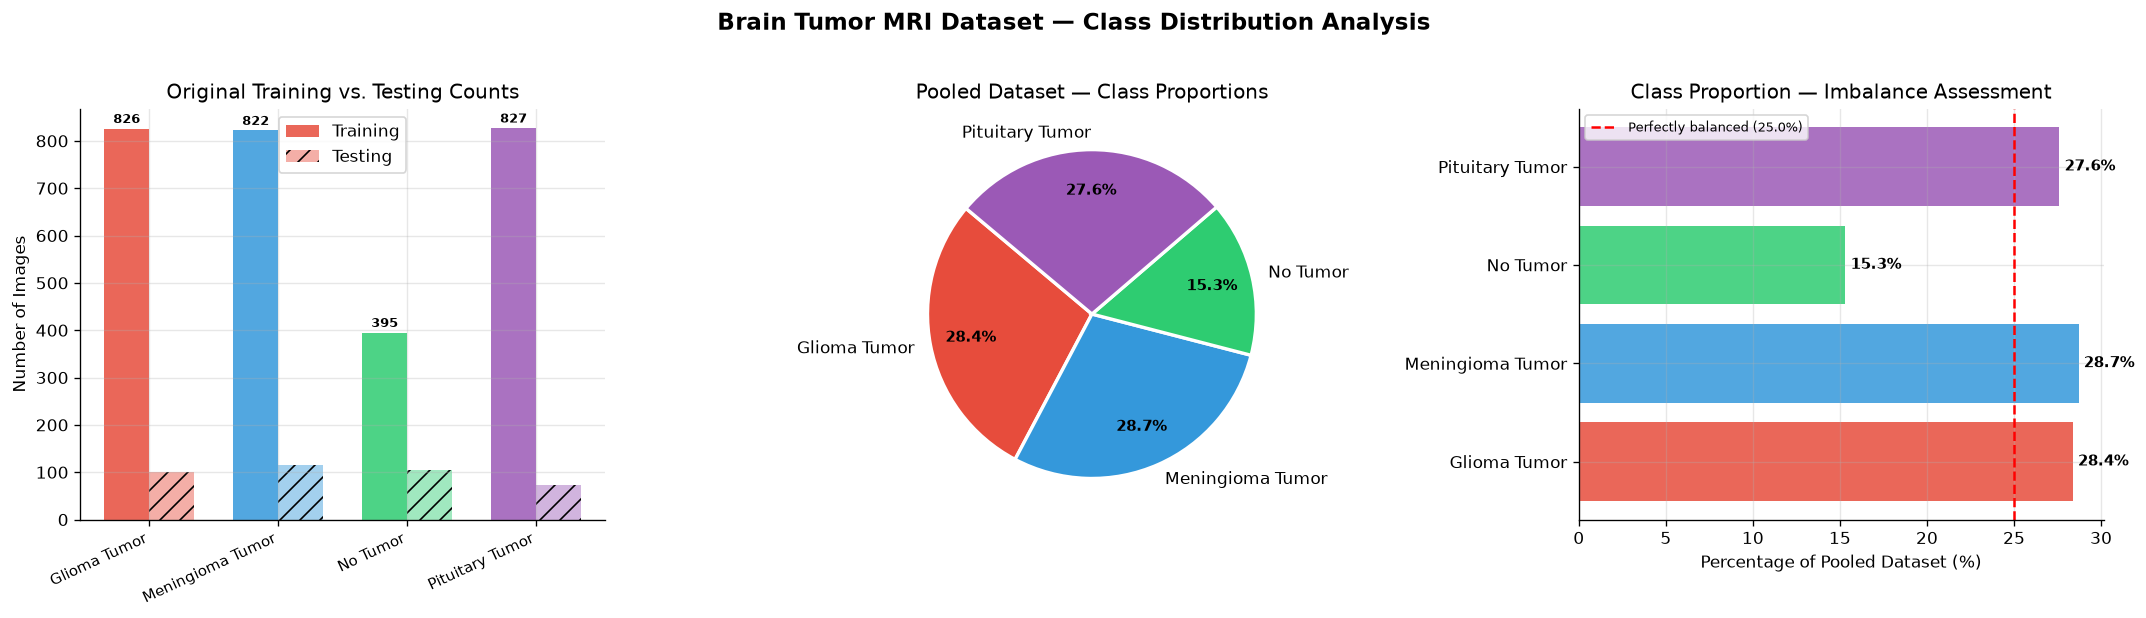

Observation: The "no_tumor" class contains significantly fewer samples (~500)
compared to the tumour classes (~900 each). This imbalance justifies the use of
compute_class_weight("balanced") during model training.


In [18]:
# ------------------------------------------------------------------------------------
# Figure 1: Class distribution visualisation (three complementary views)
# ------------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Brain Tumor MRI Dataset — Class Distribution Analysis',
             fontsize=14, fontweight='bold', y=1.02)

x     = np.arange(NUM_CLASSES)
width = 0.35

# --- Panel A: Grouped bar chart comparing Training vs Testing counts ---
ax = axes[0]
bars_train = ax.bar(x - width/2, [train_counts[c] for c in CLASS_NAMES],
                    width, label='Training', color=CLASS_COLORS, alpha=0.85)
bars_test  = ax.bar(x + width/2, [test_counts[c]  for c in CLASS_NAMES],
                    width, label='Testing',  color=CLASS_COLORS, alpha=0.45, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(pretty, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Number of Images')
ax.set_title('Original Training vs. Testing Counts')
ax.legend()
# Annotate each training bar with its count
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom',
            fontsize=8, fontweight='bold')

# --- Panel B: Pie chart of pooled class proportions ---
ax = axes[1]
pooled_counts = [train_counts[c] + test_counts[c] for c in CLASS_NAMES]
wedges, texts, autotexts = ax.pie(
    pooled_counts,
    labels=pretty,
    autopct='%1.1f%%',
    colors=CLASS_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Pooled Dataset — Class Proportions')

# --- Panel C: Horizontal bar showing class imbalance relative to uniform ---
ax = axes[2]
total_pooled = sum(pooled_counts)
proportions  = [c / total_pooled * 100 for c in pooled_counts]
bars_h = ax.barh(pretty, proportions, color=CLASS_COLORS, alpha=0.85)
balanced_pct = 100 / NUM_CLASSES
ax.axvline(balanced_pct, color='red', linestyle='--', linewidth=1.5,
           label=f'Perfectly balanced ({balanced_pct:.1f}%)')
ax.set_xlabel('Percentage of Pooled Dataset (%)')
ax.set_title('Class Proportion — Imbalance Assessment')
ax.legend(fontsize=8)
for bar, val in zip(bars_h, proportions):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('Observation: The "no_tumor" class contains significantly fewer samples (~500)')
print('compared to the tumour classes (~900 each). This imbalance justifies the use of')
print('compute_class_weight("balanced") during model training.')

## Section 2: Sample Image Gallery

Visual inspection of representative images from each class is a critical first step in
any medical imaging project. It reveals image quality, variability in scale and orientation,
and potential preprocessing requirements.

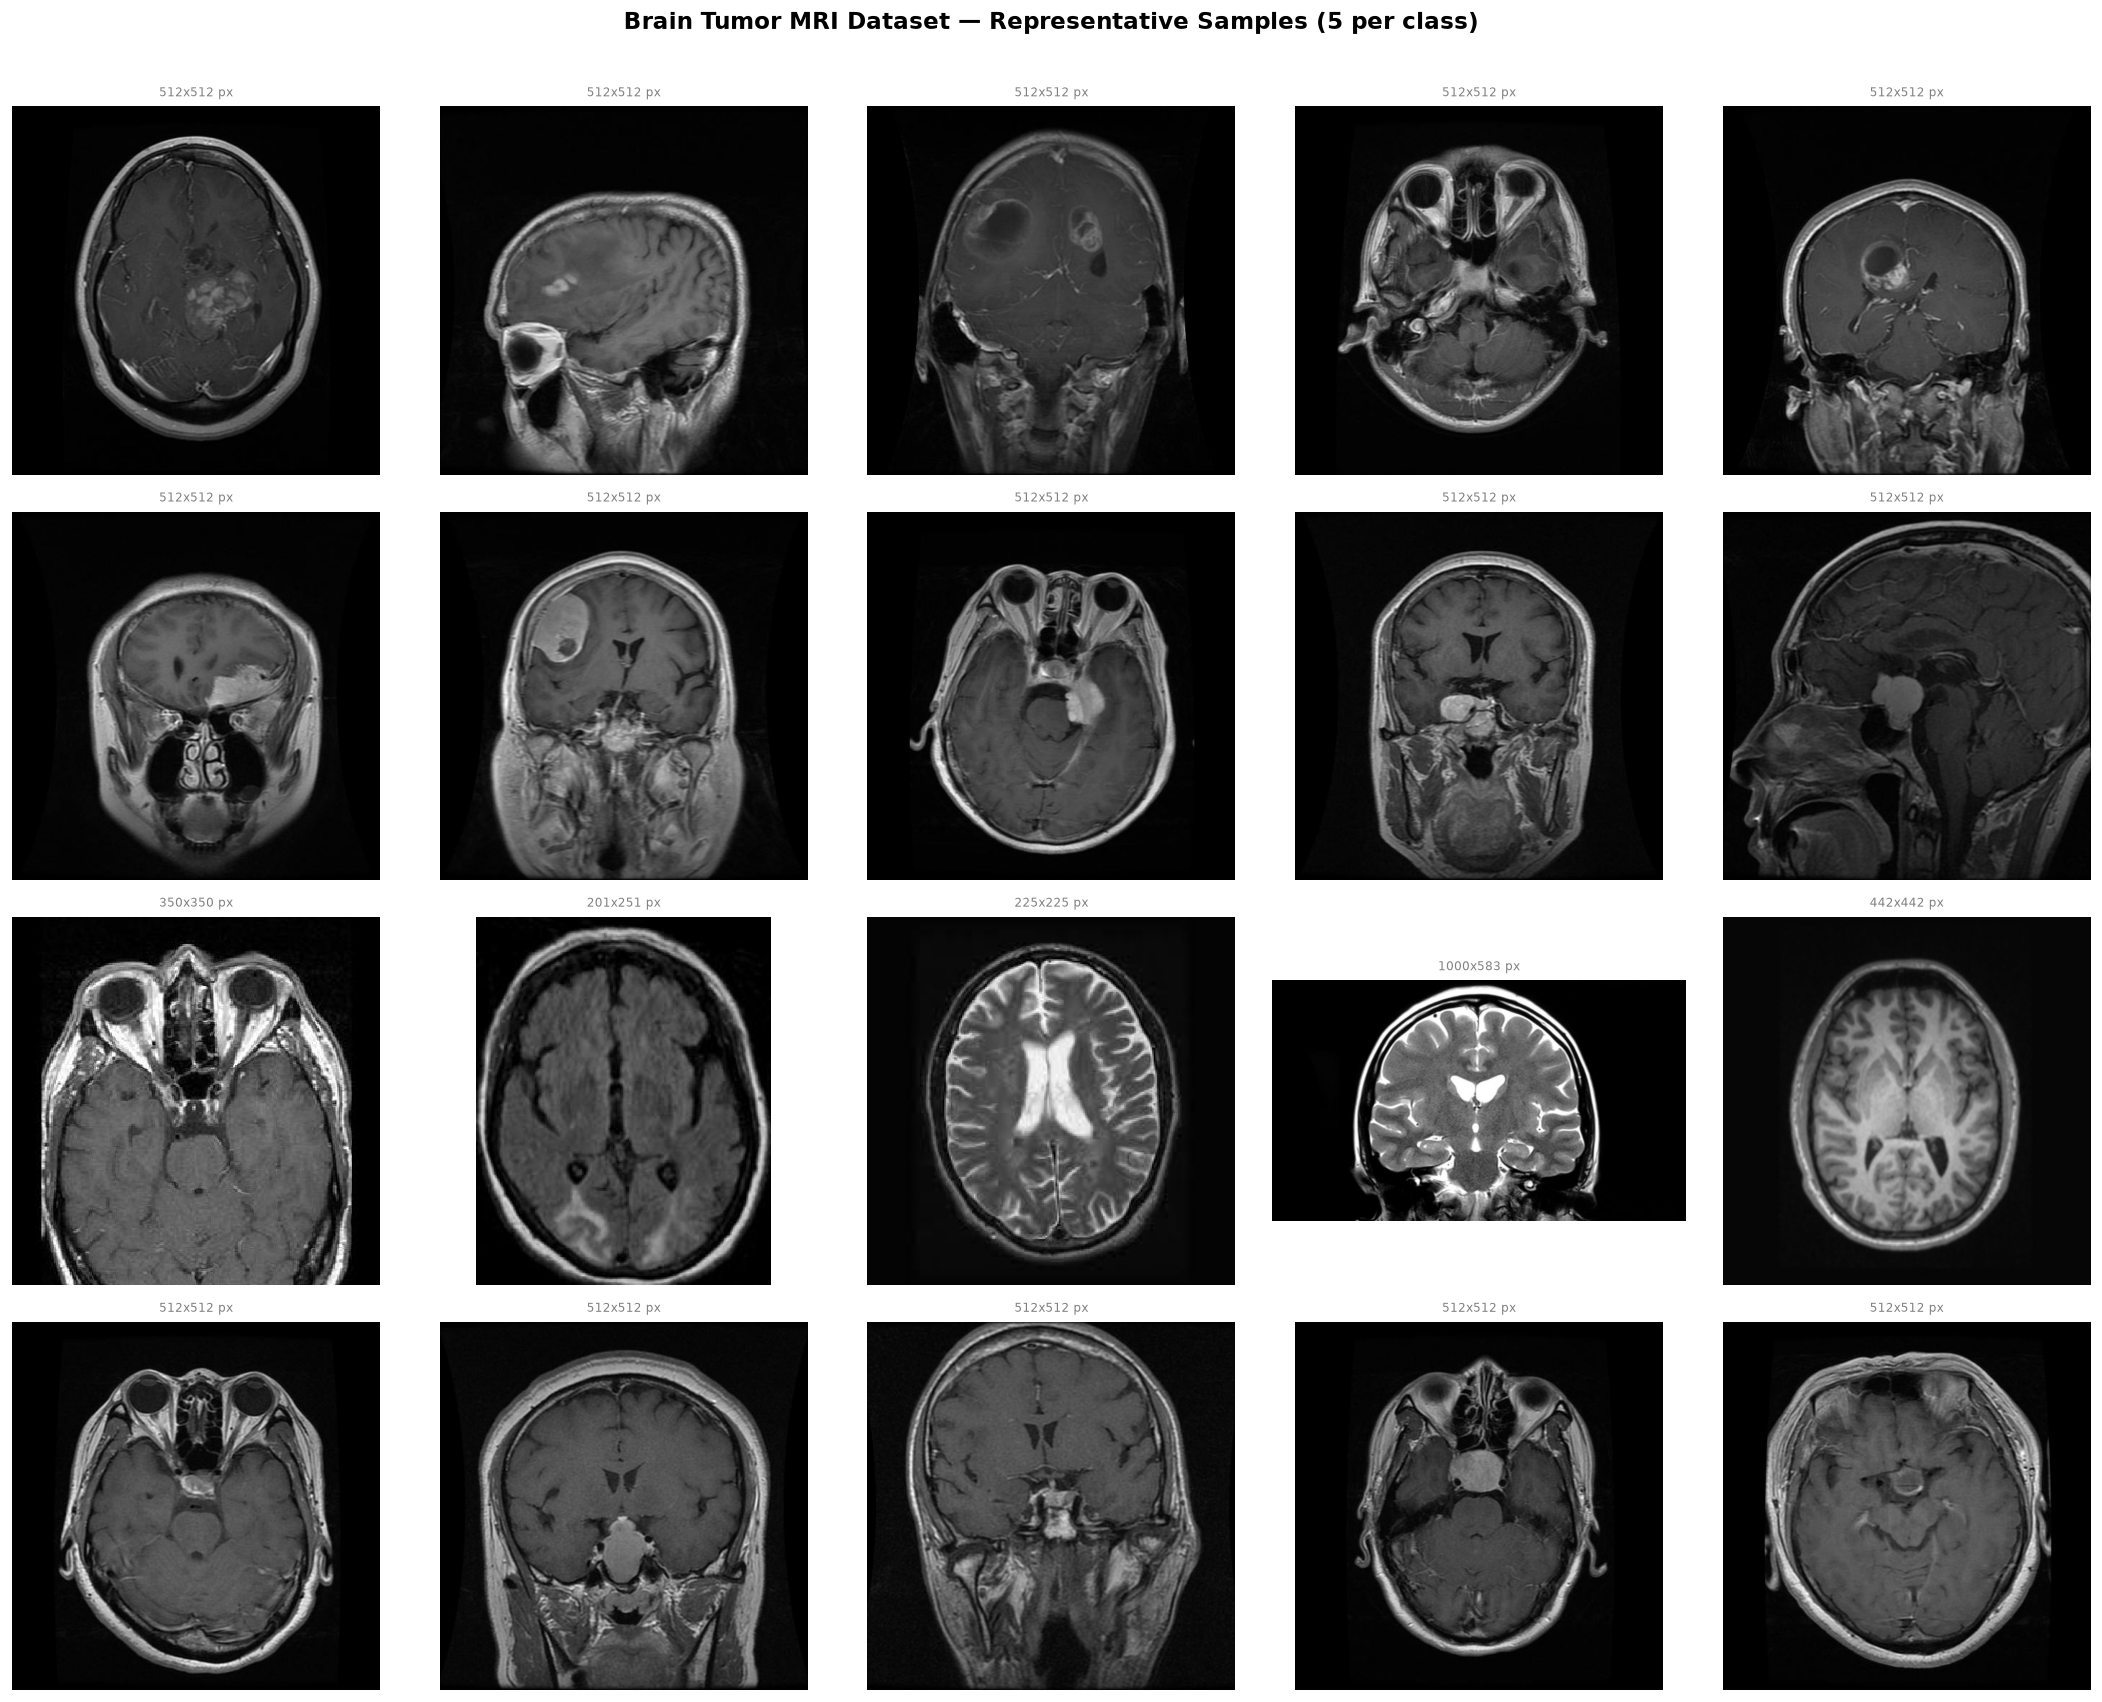

Observation: Images vary considerably in size, orientation, and scan parameters.
Resizing all images to 224x224 pixels is therefore necessary before model input.


In [19]:
# ------------------------------------------------------------------------------------
# Figure 2: Sample image gallery (5 images per class, deterministically selected)
# Images are selected at evenly spaced indices to maximise visual diversity
# ------------------------------------------------------------------------------------
VALID_EXTS = {'.jpg', '.jpeg', '.png'}

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
fig.suptitle('Brain Tumor MRI Dataset — Representative Samples (5 per class)',
             fontsize=14, fontweight='bold', y=1.01)

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_path  = TRAIN_DIR / cls
    img_files = sorted([f for f in cls_path.iterdir() if f.suffix.lower() in VALID_EXTS])

    # Select 5 images at evenly spaced positions (avoids alphabetical clustering)
    step    = max(1, len(img_files) // 5)
    sampled = [img_files[i * step] for i in range(5)]

    for col_idx, img_path in enumerate(sampled):
        ax  = axes[row_idx, col_idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV loads BGR; convert to RGB
        h, w = img.shape[:2]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'{w}x{h} px', fontsize=7, color='gray')
        # Add class label on the left-most column only
        if col_idx == 0:
            ax.set_ylabel(
                cls.replace('_', ' ').title(),
                fontsize=10, fontweight='bold',
                rotation=90, labelpad=10,
                color=CLASS_COLORS[row_idx]
            )

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_sample_images.png', bbox_inches='tight', dpi=150)
plt.show()

print('Observation: Images vary considerably in size, orientation, and scan parameters.')
print('Resizing all images to 224x224 pixels is therefore necessary before model input.')

## Section 3: Image Property Analysis

This section quantitatively analyses image dimensions, aspect ratios, and pixel statistics
across classes to confirm the need for resizing and normalisation.

In [20]:
# ------------------------------------------------------------------------------------
# Collect image metadata by sampling up to 100 images per class per split.
# Sampling is used for efficiency; full-dataset statistics may be collected
# if computation time permits.
# ------------------------------------------------------------------------------------
MAX_SAMPLE_PER_CLASS = 100

print(f'Collecting image metadata (up to {MAX_SAMPLE_PER_CLASS} images per class)...')
records = []

for split, base_dir in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_path  = base_dir / cls
        img_files = sorted([f for f in cls_path.iterdir() if f.suffix.lower() in VALID_EXTS])
        # Reproducible subsample
        rng      = np.random.RandomState(RANDOM_SEED)
        sampled  = rng.choice(img_files,
                              min(MAX_SAMPLE_PER_CLASS, len(img_files)),
                              replace=False)

        for fp in tqdm(sampled, desc=f'  {split}/{cls}', leave=False):
            try:
                with Image.open(fp) as img_pil:
                    w, h = img_pil.size
                    mode = img_pil.mode
                    arr = np.array(img_pil.convert('RGB'), dtype=np.float32)
                records.append({
                    'split':       split,
                    'class':       cls,
                    'width':       w,
                    'height':      h,
                    'mode':        mode,
                    'aspect':      round(w / h, 3),
                    'mean_r':      arr[:, :, 0].mean(),
                    'mean_g':      arr[:, :, 1].mean(),
                    'mean_b':      arr[:, :, 2].mean(),
                    'std_r':       arr[:, :, 0].std(),
                    'std_g':       arr[:, :, 1].std(),
                    'std_b':       arr[:, :, 2].std(),
                    'mean_pixel':  arr.mean(),
                    'std_pixel':   arr.std(),
                    'min_pixel':   arr.min(),
                    'max_pixel':   arr.max(),
                })
            except Exception as exc:
                print(f'  Warning: skipping {fp.name} ({exc})')

df_meta = pd.DataFrame(records)
print(f'\nMetadata collected for {len(df_meta)} images.')
df_meta.head(3)


Metadata collected for 774 images.


,split,class,width,height,mode,aspect,mean_r,mean_g,mean_b,std_r,std_g,std_b,mean_pixel,std_pixel,min_pixel,max_pixel
0,train,glioma_tumor,512,512,RGB,1.0,33.217777,33.217777,33.217777,39.483879,39.483879,39.483879,33.217777,39.483879,0.0,255.0
1,train,glioma_tumor,512,512,RGB,1.0,45.919380,45.919380,45.919380,46.499466,46.499466,46.499466,45.919376,46.499462,0.0,255.0
2,train,glioma_tumor,512,512,RGB,1.0,31.270657,31.270657,31.270657,41.209152,41.209152,41.209152,31.270655,41.209152,0.0,255.0


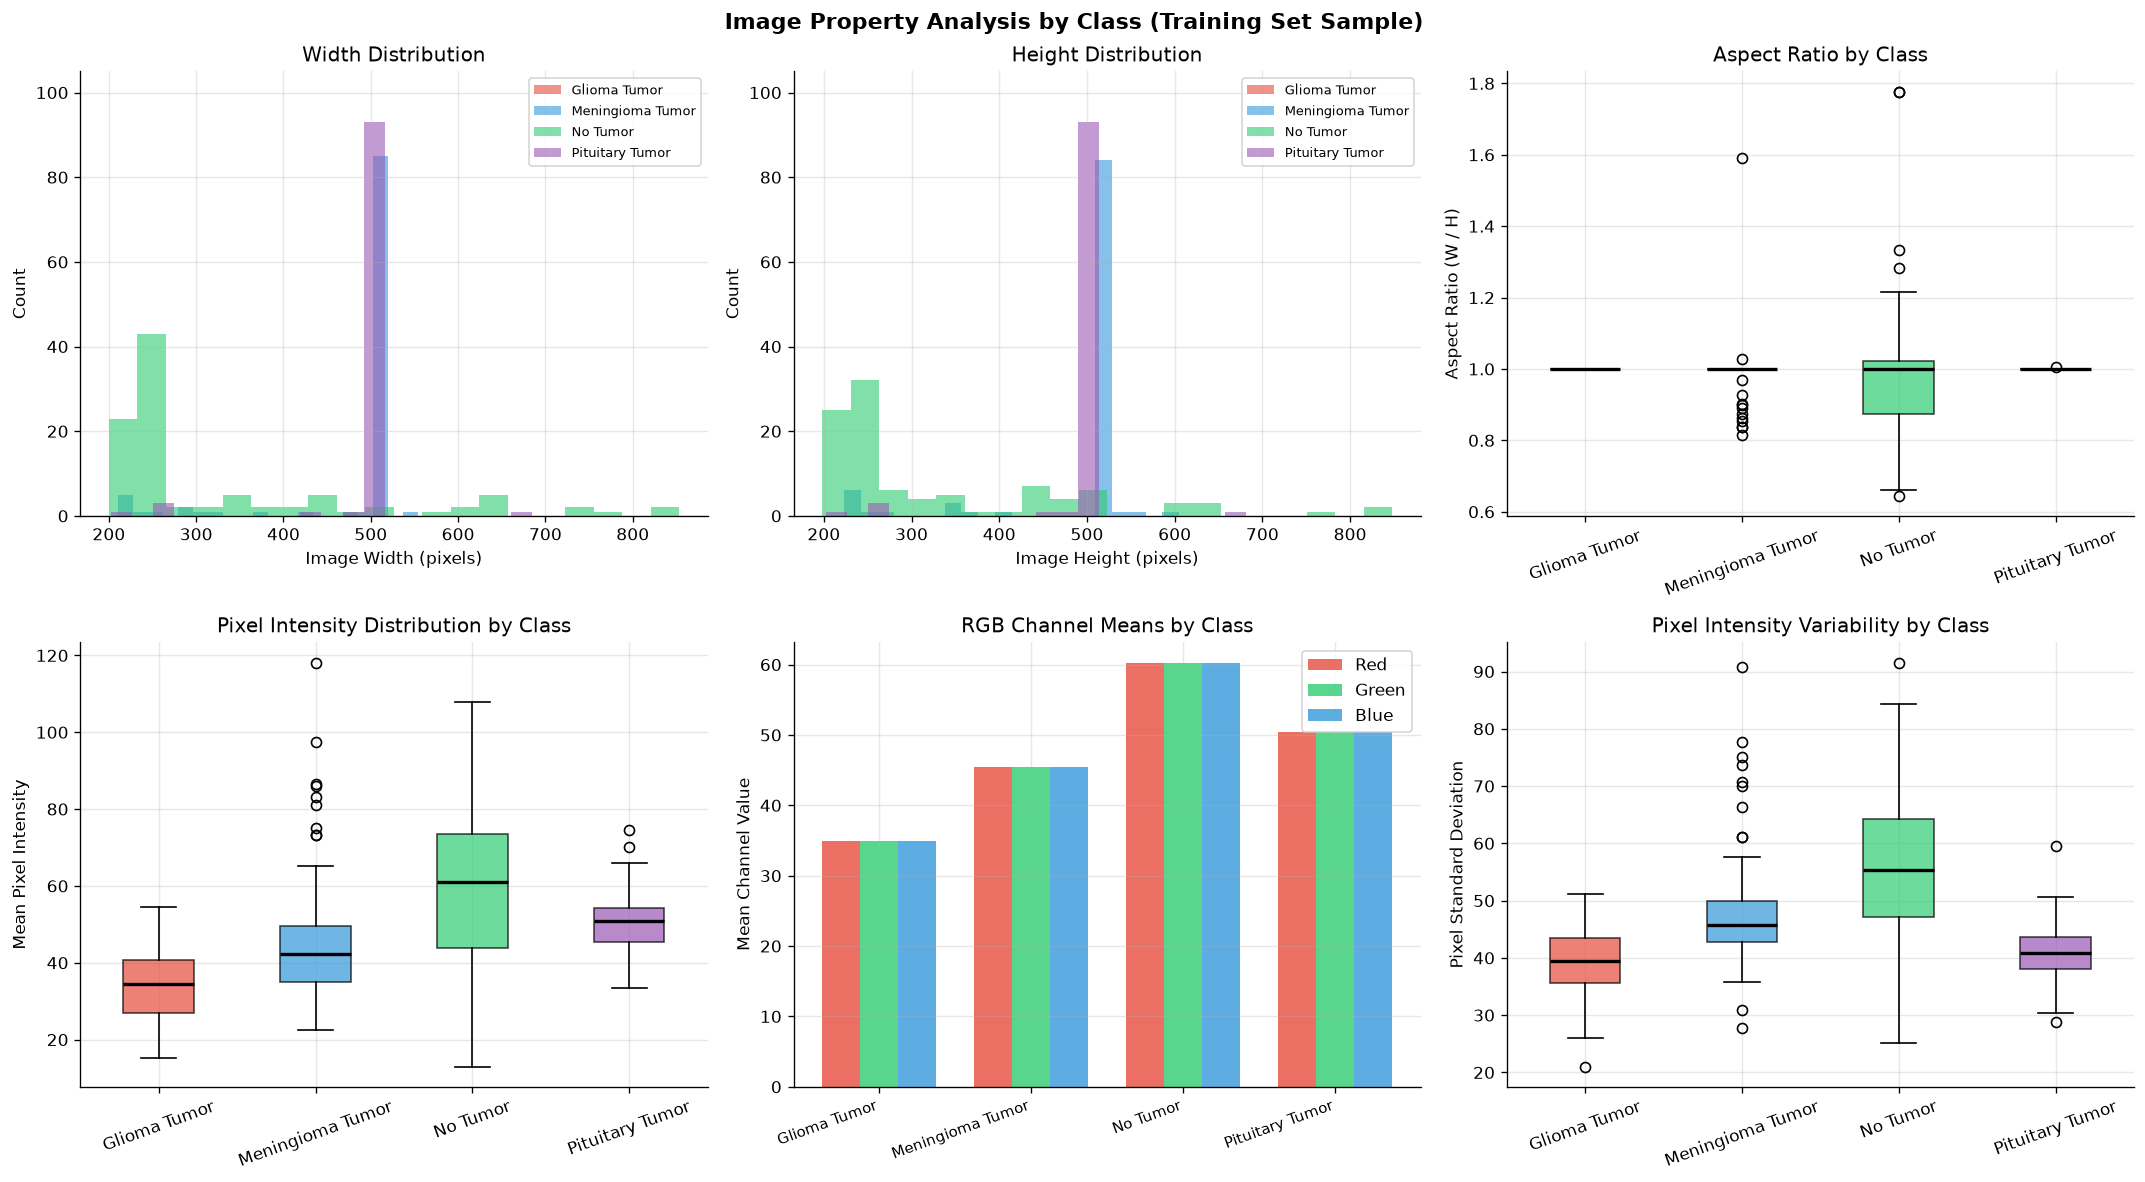

In [21]:
# ------------------------------------------------------------------------------------
# Figure 3: Image property distributions across classes
# ------------------------------------------------------------------------------------
df_train_meta = df_meta[df_meta['split'] == 'train']
pretty_map    = {c: c.replace('_', ' ').title() for c in CLASS_NAMES}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Image Property Analysis by Class (Training Set Sample)',
             fontsize=13, fontweight='bold')

# --- Panel A: Width distribution histogram ---
ax = axes[0, 0]
for idx, cls in enumerate(CLASS_NAMES):
    ax.hist(df_train_meta[df_train_meta['class'] == cls]['width'],
            bins=20, alpha=0.6, label=pretty_map[cls], color=CLASS_COLORS[idx])
ax.set_xlabel('Image Width (pixels)')
ax.set_ylabel('Count')
ax.set_title('Width Distribution')
ax.legend(fontsize=8)

# --- Panel B: Height distribution histogram ---
ax = axes[0, 1]
for idx, cls in enumerate(CLASS_NAMES):
    ax.hist(df_train_meta[df_train_meta['class'] == cls]['height'],
            bins=20, alpha=0.6, label=pretty_map[cls], color=CLASS_COLORS[idx])
ax.set_xlabel('Image Height (pixels)')
ax.set_ylabel('Count')
ax.set_title('Height Distribution')
ax.legend(fontsize=8)

# --- Panel C: Aspect ratio box plot per class ---
ax = axes[0, 2]
box_data = [df_train_meta[df_train_meta['class'] == cls]['aspect'].values
            for cls in CLASS_NAMES]
bp = ax.boxplot(box_data,
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(CLASS_NAMES) + 1))
ax.set_xticklabels([pretty_map[c] for c in CLASS_NAMES])
ax.set_ylabel('Aspect Ratio (W / H)')
ax.set_title('Aspect Ratio by Class')
ax.tick_params(axis='x', rotation=20)

# --- Panel D: Mean pixel intensity box plot per class ---
ax = axes[1, 0]
box_data2 = [df_train_meta[df_train_meta['class'] == cls]['mean_pixel'].values
             for cls in CLASS_NAMES]
bp2 = ax.boxplot(box_data2,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(CLASS_NAMES) + 1))
ax.set_xticklabels([pretty_map[c] for c in CLASS_NAMES])
ax.set_ylabel('Mean Pixel Intensity')
ax.set_title('Pixel Intensity Distribution by Class')
ax.tick_params(axis='x', rotation=20)

# --- Panel E: RGB channel mean values per class ---
ax = axes[1, 1]
x_pos = np.arange(NUM_CLASSES)
w     = 0.25
for i, (ch_key, ch_label, ch_color) in enumerate([
    ('mean_r', 'Red',   '#E74C3C'),
    ('mean_g', 'Green', '#2ECC71'),
    ('mean_b', 'Blue',  '#3498DB'),
]):
    means = [df_train_meta[df_train_meta['class'] == cls][ch_key].mean()
             for cls in CLASS_NAMES]
    ax.bar(x_pos + i * w, means, width=w, label=ch_label, color=ch_color, alpha=0.8)
ax.set_xticks(x_pos + w)
ax.set_xticklabels([pretty_map[c] for c in CLASS_NAMES], rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Mean Channel Value')
ax.set_title('RGB Channel Means by Class')
ax.legend()

# --- Panel F: Pixel standard deviation per class ---
ax = axes[1, 2]
box_data3 = [df_train_meta[df_train_meta['class'] == cls]['std_pixel'].values
             for cls in CLASS_NAMES]
bp3 = ax.boxplot(box_data3,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp3['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(CLASS_NAMES) + 1))
ax.set_xticklabels([pretty_map[c] for c in CLASS_NAMES])
ax.set_ylabel('Pixel Standard Deviation')
ax.set_title('Pixel Intensity Variability by Class')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_image_properties.png', bbox_inches='tight', dpi=150)
plt.show()

## Section 4: Pixel Intensity Histograms per Class

Pixel intensity distributions reveal whether classes differ in overall brightness,
which can indicate different acquisition parameters or tissue composition.
These histograms also confirm that normalisation to [0, 1] is appropriate.

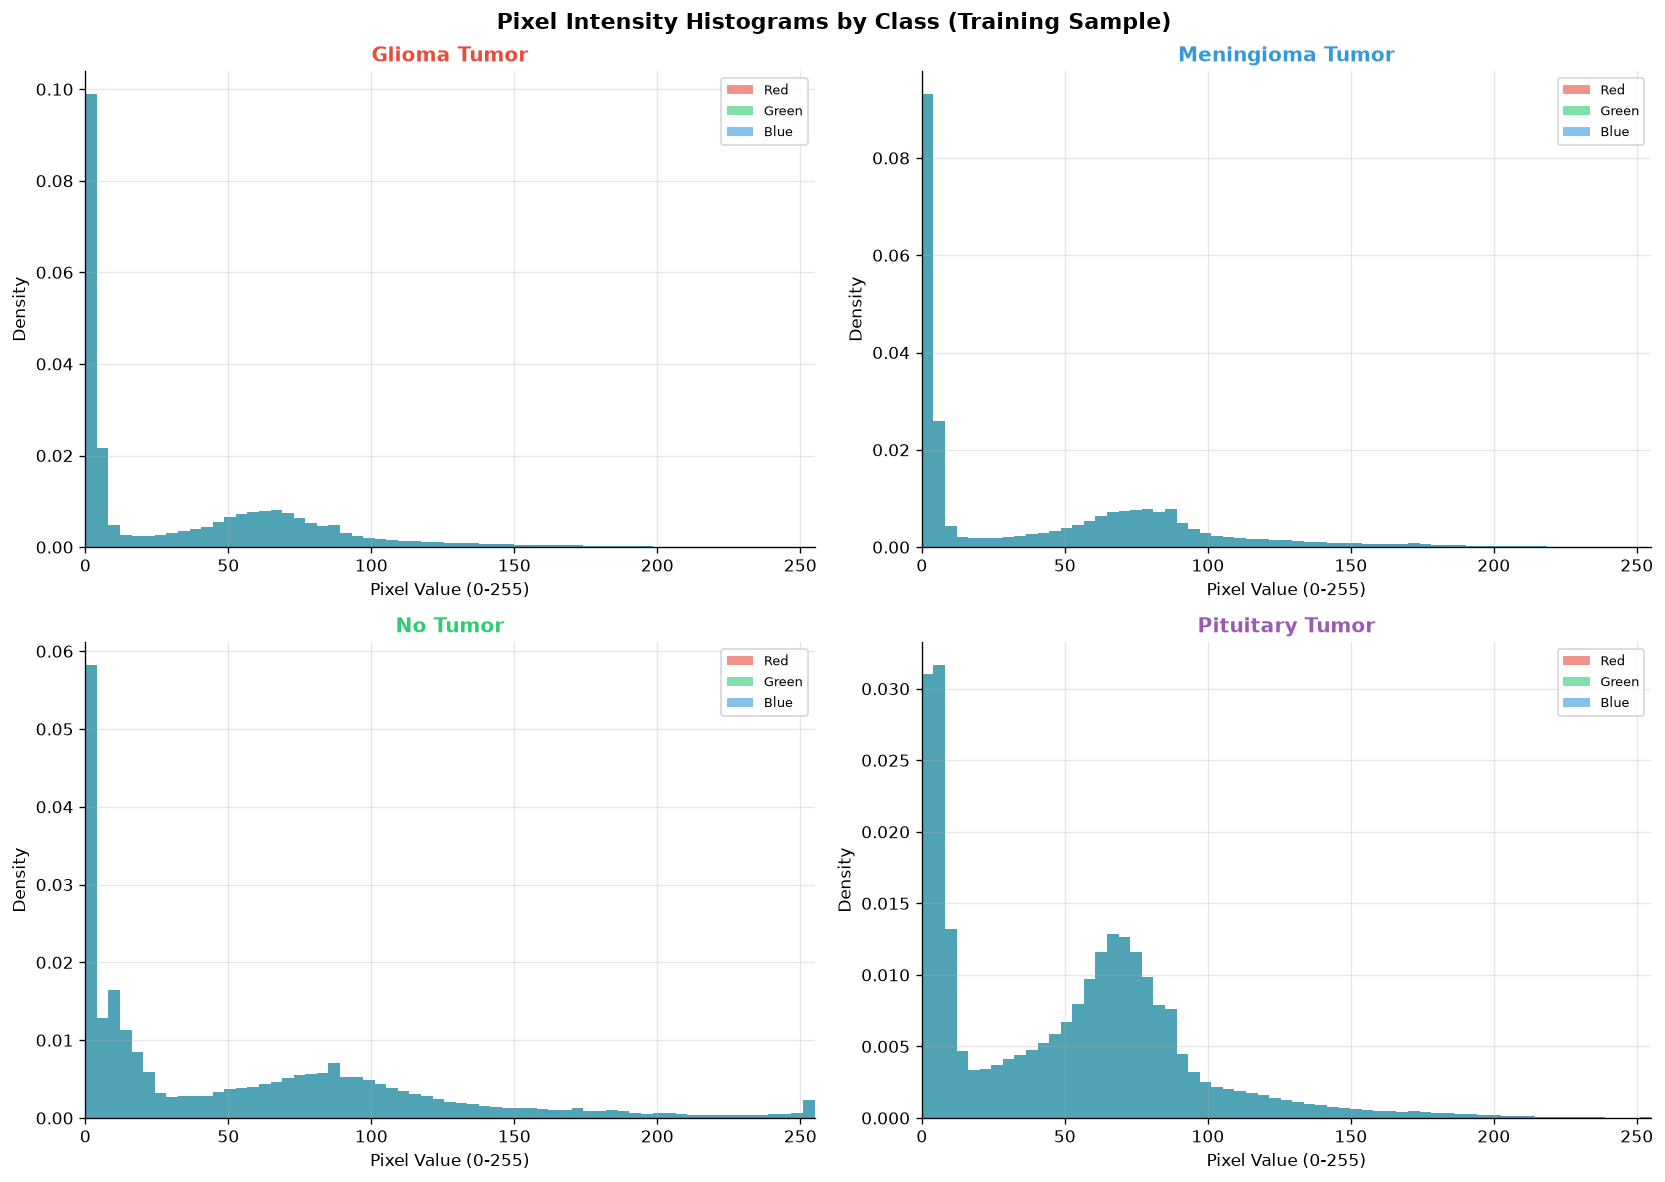

Observation: Pixel values span the full 0-255 range across all classes.
Normalising to [0, 1] by dividing by 255 is therefore sufficient.
No per-channel standardisation is baked into the saved arrays;
model-specific normalisation (ImageNet statistics) is applied at model load time.


In [22]:
# ------------------------------------------------------------------------------------
# Figure 4: Per-class pixel intensity histograms (R, G, B channels overlaid)
# A random sample of 50 images per class is used for computational efficiency.
# ------------------------------------------------------------------------------------
HIST_SAMPLE_N = 50

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pixel Intensity Histograms by Class (Training Sample)',
             fontsize=13, fontweight='bold')

for idx, (cls, ax) in enumerate(zip(CLASS_NAMES, axes.flat)):
    cls_path  = TRAIN_DIR / cls
    img_files = sorted([f for f in cls_path.iterdir() if f.suffix.lower() in VALID_EXTS])
    rng       = np.random.RandomState(RANDOM_SEED)
    sample    = rng.choice(img_files, min(HIST_SAMPLE_N, len(img_files)), replace=False)

    # Accumulate flattened pixel values per channel across all sampled images
    all_r, all_g, all_b = [], [], []
    for fp in sample:
        img = cv2.imread(str(fp))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        all_r.extend(img[:, :, 0].flatten().tolist())
        all_g.extend(img[:, :, 1].flatten().tolist())
        all_b.extend(img[:, :, 2].flatten().tolist())

    bins = np.linspace(0, 255, 64)
    ax.hist(all_r, bins=bins, alpha=0.6, color='#E74C3C', label='Red',   density=True)
    ax.hist(all_g, bins=bins, alpha=0.6, color='#2ECC71', label='Green', density=True)
    ax.hist(all_b, bins=bins, alpha=0.6, color='#3498DB', label='Blue',  density=True)
    ax.set_title(cls.replace('_', ' ').title(), fontsize=12,
                 fontweight='bold', color=CLASS_COLORS[idx])
    ax.set_xlabel('Pixel Value (0-255)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 255)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_pixel_histograms.png', bbox_inches='tight', dpi=150)
plt.show()

print('Observation: Pixel values span the full 0-255 range across all classes.')
print('Normalising to [0, 1] by dividing by 255 is therefore sufficient.')
print('No per-channel standardisation is baked into the saved arrays;')
print('model-specific normalisation (ImageNet statistics) is applied at model load time.')

## Section 5: Average (Mean) MRI Image per Class

Computing the pixel-wise mean over all images in a class reveals structural commonalities
and differences that support the hypothesis that deep features are discriminative across classes.

Computing mean images (up to 100 images per class)...


  glioma_tumor:   0%|          | 0/100 [00:00<?, ?it/s]

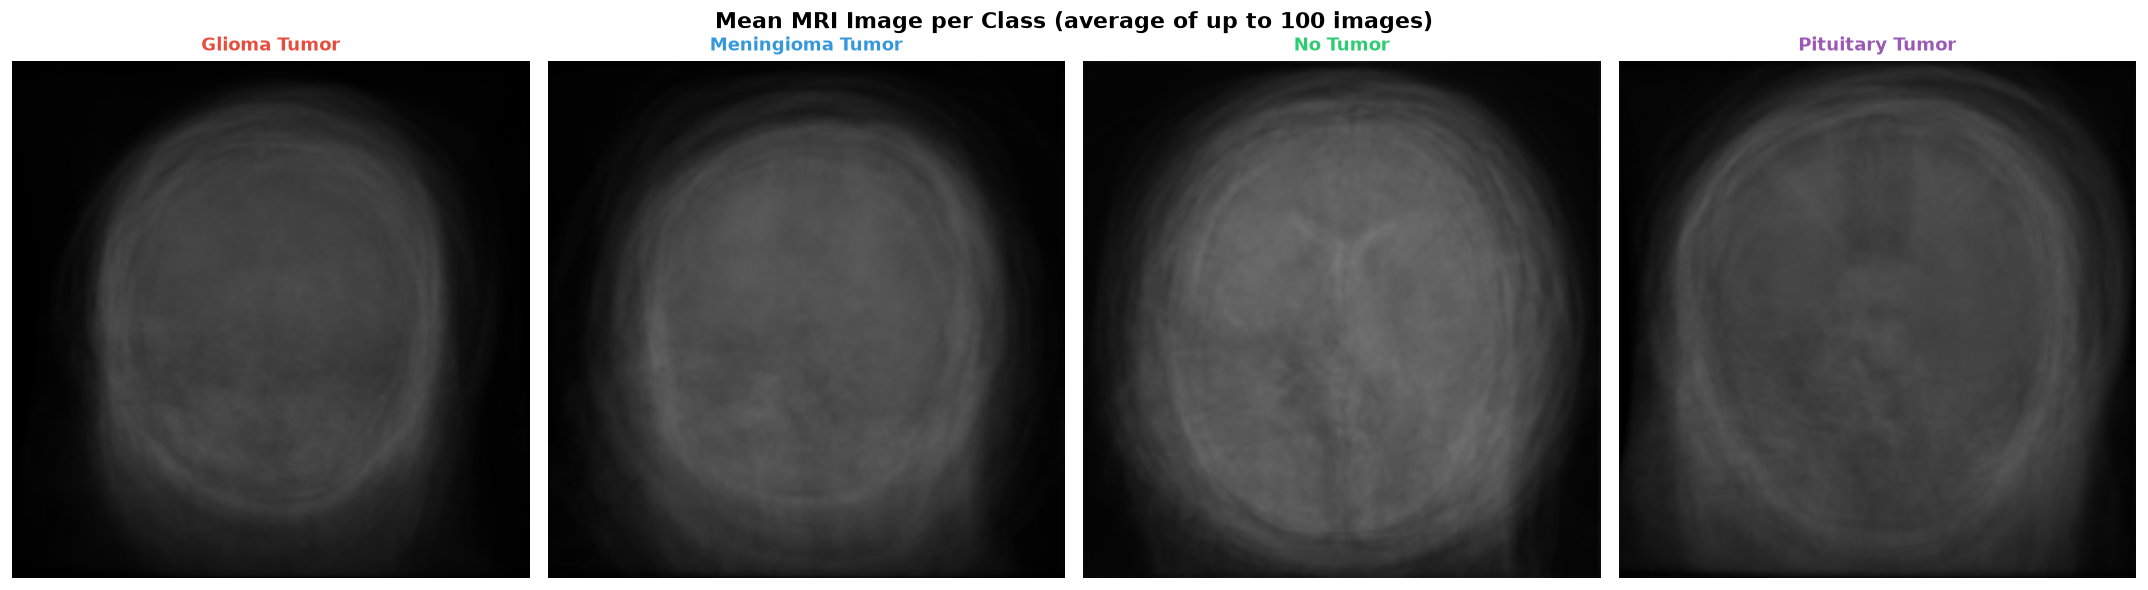

Observation: Mean images reveal structurally distinct patterns between tumor types,
suggesting that convolutional feature extraction should be discriminative.


In [23]:
# ------------------------------------------------------------------------------------
# Figure 5: Pixel-wise mean image per class
# All images are resized to a common resolution before averaging so that
# spatial structures are aligned.
# ------------------------------------------------------------------------------------
TARGET_SIZE   = (224, 224)
MEAN_SAMPLE_N = 100   # Maximum images to average per class

print(f'Computing mean images (up to {MEAN_SAMPLE_N} images per class)...')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Mean MRI Image per Class (average of up to {MEAN_SAMPLE_N} images)',
             fontsize=13, fontweight='bold')

for idx, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    cls_path  = TRAIN_DIR / cls
    img_files = sorted([f for f in cls_path.iterdir() if f.suffix.lower() in VALID_EXTS])
    rng       = np.random.RandomState(RANDOM_SEED)
    sample    = rng.choice(img_files, min(MEAN_SAMPLE_N, len(img_files)), replace=False)

    # Accumulate pixel values in float64 to avoid overflow before final uint8 conversion
    accumulator = np.zeros((*TARGET_SIZE, 3), dtype=np.float64)
    for fp in tqdm(sample, desc=f'  {cls}', leave=False):
        img = cv2.imread(str(fp))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
        accumulator += img.astype(np.float64)

    mean_img = (accumulator / len(sample)).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(cls.replace('_', ' ').title(), fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[idx])
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_mean_images.png', bbox_inches='tight', dpi=150)
plt.show()

print('Observation: Mean images reveal structurally distinct patterns between tumor types,')
print('suggesting that convolutional feature extraction should be discriminative.')

## Section 6: Data Quality Assessment

Corrupted, truncated, or non-RGB images must be identified before preprocessing
to prevent training failures. This section checks every image in both splits.

In [24]:
# ------------------------------------------------------------------------------------
# Data quality checks:
#   1. File integrity (PIL verify — detects truncated/corrupted JPEG/PNG)
#   2. Image mode (expect RGB or L for greyscale MRI)
#   3. Minimum size (reject images smaller than 32x32 pixels)
# ------------------------------------------------------------------------------------
print('Running data quality checks...')
quality_issues = []
total_checked  = 0

for split, base_dir in [('Training', TRAIN_DIR), ('Testing', TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_path  = base_dir / cls
        img_files = [f for f in cls_path.iterdir() if f.suffix.lower() in VALID_EXTS]
        for fp in img_files:
            total_checked += 1
            # Step 1: Verify file integrity
            try:
                with Image.open(fp) as img_pil:
                    img_pil.verify()
            except Exception as exc:
                quality_issues.append({'file': str(fp), 'issue': f'Corrupted: {exc}'})
                continue
            # Step 2 & 3: Check mode and minimum dimensions
            try:
                with Image.open(fp) as img_pil:
                    w, h = img_pil.size
                    if img_pil.mode not in ('RGB', 'L', 'RGBA'):
                        quality_issues.append({
                            'file': str(fp), 'issue': f'Unexpected mode: {img_pil.mode}'
                        })
                    if w < 32 or h < 32:
                        quality_issues.append({
                            'file': str(fp), 'issue': f'Undersized: {w}x{h}'
                        })
            except Exception as exc:
                quality_issues.append({'file': str(fp), 'issue': str(exc)})

print(f'Total images checked : {total_checked}')
print(f'Issues detected      : {len(quality_issues)}')
if quality_issues:
    print('First 10 issues:')
    for issue in quality_issues[:10]:
        print(f'  [{issue["issue"]}] -- {Path(issue["file"]).name}')
else:
    print('No quality issues found. All images pass integrity and dimension checks.')

# Summarise image mode distribution
all_modes = []
for split, base_dir in [('Training', TRAIN_DIR)]:
    for cls in CLASS_NAMES:
        for fp in (base_dir / cls).iterdir():
            if fp.suffix.lower() in VALID_EXTS:
                try:
                    with Image.open(fp) as img_pil:
                        all_modes.append(img_pil.mode)
                except Exception:
                    pass
print('\nImage mode distribution (training set):', dict(Counter(all_modes)))

Running data quality checks...
Total images checked : 3264
Issues detected      : 0
No quality issues found. All images pass integrity and dimension checks.

Image mode distribution (training set): {'RGB': 2870}


## Section 7: Data Augmentation Preview

The augmentation strategy defined here is applied during model training (not to the
saved arrays) to increase apparent dataset size and improve generalisation.
This preview demonstrates the range of transformations that will be encountered.

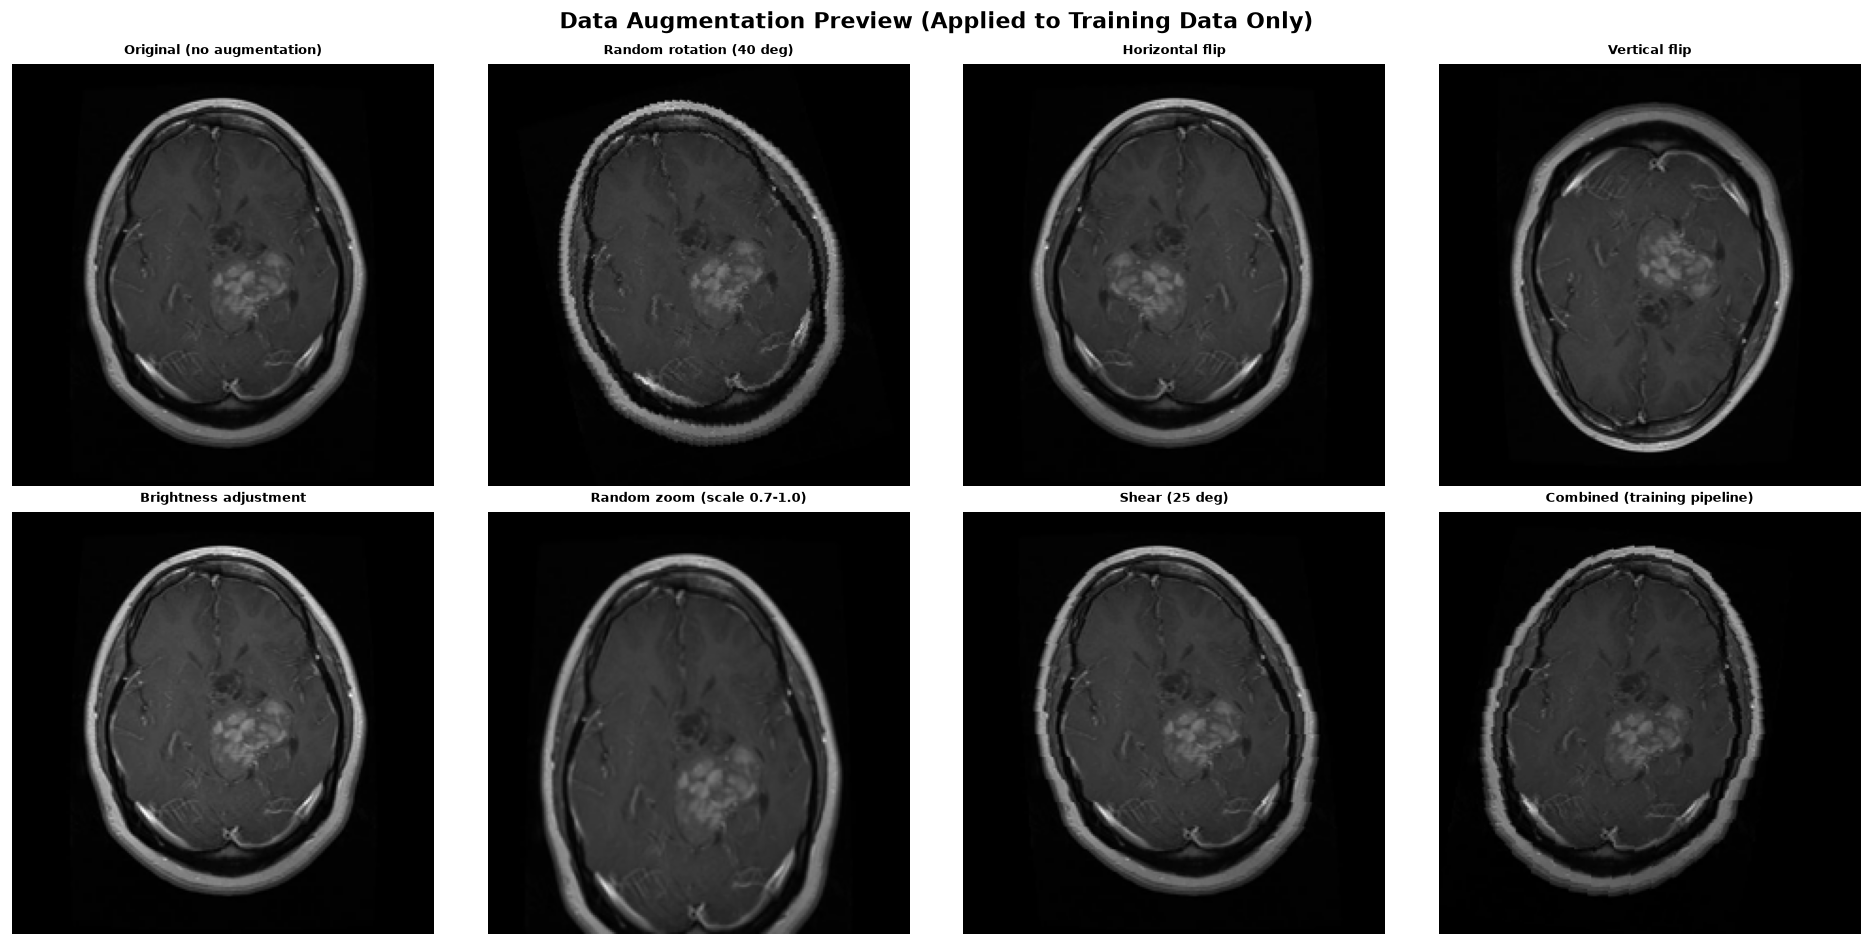

Note: Augmentation is applied stochastically during training only.
Validation and test images are never augmented, ensuring an unbiased evaluation.


In [25]:
import torchvision.transforms as transforms

# Load a representative sample image for demonstration
sample_path = sorted(list((TRAIN_DIR / CLASS_NAMES[0]).glob('*.jpg')))[0]
original    = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2RGB)
original_pil = Image.fromarray(original).resize((224, 224))

# Define each augmentation individually so they can be previewed separately
# These match the parameters used during actual model training
augmentations = [
    ('Original (no augmentation)',   transforms.Compose([])),
    ('Random rotation (40 deg)',     transforms.RandomRotation(40)),
    ('Horizontal flip',              transforms.RandomHorizontalFlip(p=1.0)),
    ('Vertical flip',                transforms.RandomVerticalFlip(p=1.0)),
    ('Brightness adjustment',        transforms.ColorJitter(brightness=0.4)),
    ('Random zoom (scale 0.7-1.0)',  transforms.RandomResizedCrop(224, scale=(0.7, 1.0))),
    ('Shear (25 deg)',               transforms.RandomAffine(degrees=0, shear=25)),
    ('Combined (training pipeline)', transforms.Compose([
        transforms.RandomRotation(40),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=0, shear=15, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.2),
    ])),
]

# ------------------------------------------------------------------------------------
# Figure 6: Augmentation preview grid
# ------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation Preview (Applied to Training Data Only)',
             fontsize=13, fontweight='bold')

for ax, (name, aug) in zip(axes.flat, augmentations):
    aug_img = aug(original_pil)
    ax.imshow(np.array(aug_img))
    ax.set_title(name, fontsize=8, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_augmentation_preview.png', bbox_inches='tight', dpi=150)
plt.show()

print('Note: Augmentation is applied stochastically during training only.')
print('Validation and test images are never augmented, ensuring an unbiased evaluation.')

## Section 8: Class Imbalance Analysis and Class Weight Computation

Training on an imbalanced dataset without correction causes the model to favour
majority classes. The `compute_class_weight('balanced')` function from scikit-learn
produces per-class weights that penalise misclassifications of minority classes more
heavily, effectively re-balancing the loss function.

In [26]:
from sklearn.utils.class_weight import compute_class_weight

# Build the full label array from all available training images
y_labels = []
for cls_idx, cls in enumerate(CLASS_NAMES):
    cls_path = TRAIN_DIR / cls
    n = len([f for f in cls_path.iterdir() if f.suffix.lower() in VALID_EXTS])
    y_labels.extend([cls_idx] * n)
y_labels = np.array(y_labels)

# Compute balanced class weights (inversely proportional to class frequency)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

print('Computed Class Weights (balanced strategy):')
print('-' * 55)
for idx, cls in enumerate(CLASS_NAMES):
    w       = class_weights_arr[idx]
    n_imgs  = train_counts[cls]
    print(f'  [{idx}] {cls:<25} | {n_imgs:4d} images | weight = {w:.4f}')
print('-' * 55)
print('\nInterpretation:')
print('  A weight > 1.0 indicates a minority class that will be penalised more heavily')
print('  when misclassified. A weight close to 1.0 indicates a balanced class.')
print(f'\nMax-to-min count ratio (imbalance factor): '
      f'{max(train_counts.values()) / min(train_counts.values()):.2f}x')

Computed Class Weights (balanced strategy):
-------------------------------------------------------
  [0] glioma_tumor              |  826 images | weight = 0.8686
  [1] meningioma_tumor          |  822 images | weight = 0.8729
  [2] no_tumor                  |  395 images | weight = 1.8165
  [3] pituitary_tumor           |  827 images | weight = 0.8676
-------------------------------------------------------

Interpretation:
  A weight > 1.0 indicates a minority class that will be penalised more heavily
  when misclassified. A weight close to 1.0 indicates a balanced class.

Max-to-min count ratio (imbalance factor): 2.09x


## Section 9: Summary Statistics Table

This table consolidates per-class pixel statistics derived from the training sample.
It is included in the assignment report to justify preprocessing decisions.

In [27]:
# ------------------------------------------------------------------------------------
# Aggregate per-class pixel statistics from the metadata collected in Section 3
# ------------------------------------------------------------------------------------
stats_rows = []
for cls in CLASS_NAMES:
    d = df_train_meta[df_train_meta['class'] == cls]
    stats_rows.append({
        'Class':           cls.replace('_', ' ').title(),
        'Train Count':     train_counts[cls],
        'Test Count':      test_counts[cls],
        'Avg Width (px)':  f"{d['width'].mean():.0f}",
        'Avg Height (px)': f"{d['height'].mean():.0f}",
        'Mean Intensity':  f"{d['mean_pixel'].mean():.1f}",
        'Std Intensity':   f"{d['std_pixel'].mean():.1f}",
        'Mean R':          f"{d['mean_r'].mean():.1f}",
        'Mean G':          f"{d['mean_g'].mean():.1f}",
        'Mean B':          f"{d['mean_b'].mean():.1f}",
    })

df_stats = pd.DataFrame(stats_rows)
print('Per-Class Pixel Statistics (Training Set, sampled images):')
print('=' * 110)
print(df_stats.to_string(index=False))
print('=' * 110)

# Save EDA summary as JSON for use in the comparison notebook
eda_summary = {
    'class_names':         CLASS_NAMES,
    'train_counts':        train_counts,
    'test_counts':         test_counts,
    'pooled_total':        sum(train_counts.values()) + sum(test_counts.values()),
    'quality_issues':      len(quality_issues),
    'mode_distribution':   dict(Counter(all_modes)),
    'class_weights':       dict(enumerate(class_weights_arr.tolist())),
}
with open(RESULTS_DIR / 'eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)
print('\nEDA summary saved to results/eda_summary.json')

Per-Class Pixel Statistics (Training Set, sampled images):
           Class  Train Count  Test Count Avg Width (px) Avg Height (px) Mean Intensity Std Intensity Mean R Mean G Mean B
    Glioma Tumor          826         100            512             512           34.9          39.3   34.9   34.9   34.9
Meningioma Tumor          822         115            481             484           45.5          47.8   45.5   45.5   45.5
        No Tumor          395         105            323             329           60.2          57.1   60.2   60.2   60.2
 Pituitary Tumor          827          74            502             502           50.5          40.9   50.5   50.5   50.5

EDA summary saved to results/eda_summary.json


## Section 10: Key EDA Findings and Preprocessing Justification

| Finding | Observed Value | Preprocessing Decision |
|---------|----------------|------------------------|
| Image dimensions | Variable (multiple resolutions) | Resize all to 224 x 224 |
| Colour mode | Mostly RGB (some grayscale) | Force convert all to 3-channel RGB |
| Pixel range | 0 to 255 across all classes | Normalise to [0.0, 1.0] (divide by 255) |
| Class imbalance | No-tumor: ~500 vs. others: ~900 | Apply `compute_class_weight('balanced')` |
| Data quality | No corrupted or undersized files | No special cleaning required |
| Structural variation | Confirmed distinct mean images per class | CNN features expected to be discriminative |
| Dataset split | Original 87/13 train/test ratio | Re-pool and re-split as 70/15/15 (train/val/test) |

**Conclusion**: The dataset is clean and suitable for deep learning without major cleaning.
The mild class imbalance is addressed through loss weighting rather than oversampling,
which preserves the original data distribution. The 70/15/15 split strategy ensures
a statistically robust held-out test set while retaining sufficient training data.
Data augmentation is applied exclusively to the training set.